In [1]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
username = "your_username"
password = "your_password"
conn = wrds.Connection(username=username, password=password)
print("Connection successful")

Enter your WRDS username [pangjunman]: nlrb
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Connection successful


In [3]:
# Define tickers and date range
tickers = ['AAPL', 'TSLA']
start_date = '2020-01-01'
end_date = '2022-12-31'
print("Tickers:", tickers)
print("Date range:", start_date, "to", end_date)

Tickers: ['AAPL', 'TSLA']
Date range: 2020-01-01 to 2022-12-31


In [8]:
# Fetch TSLA data
sql_tsla = f"""
    SELECT a.date, a.ret, a.vol, b.htsymbol
    FROM crsp.msf a
    LEFT JOIN crsp.msfhdr b ON a.permno = b.permno
    WHERE b.htsymbol = 'TSLA'
      AND a.date BETWEEN '{start_date}' AND '{end_date}'
    ORDER BY a.date
"""
df_tsla = conn.raw_sql(sql_tsla, date_cols=['date'])
print(f"TSLA: {len(df_tsla)} records retrieved")
df_tsla.head()

TSLA: 36 records retrieved


,date,ret,vol,htsymbol
0,2020-01-31,0.55516,4072082.0,TSLA
1,2020-02-28,0.026777,4720676.0,TSLA
2,2020-03-31,-0.215557,4200834.0,TSLA
3,2020-04-30,0.492137,3806580.0,TSLA
4,2020-05-29,0.067939,2723026.0,TSLA


In [9]:
# Fetch AAPL data
sql_aapl = f"""
    SELECT a.date, a.ret, a.vol, b.htsymbol
    FROM crsp.msf a
    LEFT JOIN crsp.msfhdr b ON a.permno = b.permno
    WHERE b.htsymbol = 'AAPL'
      AND a.date BETWEEN '{start_date}' AND '{end_date}'
    ORDER BY a.date
"""
df_aapl = conn.raw_sql(sql_aapl, date_cols=['date'])
print(f"AAPL: {len(df_aapl)} records retrieved")
df_aapl.head()

AAPL: 36 records retrieved


,date,ret,vol,htsymbol
0,2020-01-31,0.05401,7346625.0,AAPL
1,2020-02-28,-0.11431,7538341.0,AAPL
2,2020-03-31,-0.069762,15678412.0,AAPL
3,2020-04-30,0.155374,8151167.0,AAPL
4,2020-05-29,0.084956,7011777.0,AAPL


In [10]:
# Clean AAPL data
df_aapl = df_aapl.rename(columns={'ret': 'monthly_return', 'vol': 'volume', 'htsymbol': 'ticker'})
df_aapl = df_aapl[df_aapl['monthly_return'].notna()]
print(f"AAPL after cleaning: {len(df_aapl)} records")

AAPL after cleaning: 36 records


In [11]:
# Clean TSLA data
df_tsla = df_tsla.rename(columns={'ret': 'monthly_return', 'vol': 'volume', 'htsymbol': 'ticker'})
df_tsla = df_tsla[df_tsla['monthly_return'].notna()]
print(f"TSLA after cleaning: {len(df_tsla)} records")

TSLA after cleaning: 36 records


In [12]:
# Close WRDS connection
conn.close()
print("WRDS connection closed")

WRDS connection closed


In [13]:
# Descriptive statistics for AAPL
mean_aapl = df_aapl['monthly_return'].mean() * 100
std_aapl = df_aapl['monthly_return'].std() * 100
print(f"AAPL - Average monthly return: {mean_aapl:.2f}%")
print(f"AAPL - Volatility (std): {std_aapl:.2f}%")

AAPL - Average monthly return: 2.10%
AAPL - Volatility (std): 9.69%


In [14]:
# Descriptive statistics for TSLA
mean_tsla = df_tsla['monthly_return'].mean() * 100
std_tsla = df_tsla['monthly_return'].std() * 100
print(f"TSLA - Average monthly return: {mean_tsla:.2f}%")
print(f"TSLA - Volatility (std): {std_tsla:.2f}%")

TSLA - Average monthly return: 6.82%
TSLA - Volatility (std): 24.92%


In [15]:
# Highest and lowest monthly returns for AAPL
max_aapl = df_aapl.loc[df_aapl['monthly_return'].idxmax()]
min_aapl = df_aapl.loc[df_aapl['monthly_return'].idxmin()]
print("AAPL:")
print(f"  Highest monthly return: {max_aapl['monthly_return']*100:.2f}% ({max_aapl['date'].strftime('%Y-%m')})")
print(f"  Lowest monthly return: {min_aapl['monthly_return']*100:.2f}% ({min_aapl['date'].strftime('%Y-%m')})")

AAPL:
  Highest monthly return: 21.63% (2020-08)
  Lowest monthly return: -12.23% (2022-12)


In [16]:
# Highest and lowest monthly returns for TSLA
max_tsla = df_tsla.loc[df_tsla['monthly_return'].idxmax()]
min_tsla = df_tsla.loc[df_tsla['monthly_return'].idxmin()]
print("TSLA:")
print(f"  Highest monthly return: {max_tsla['monthly_return']*100:.2f}% ({max_tsla['date'].strftime('%Y-%m')})")
print(f"  Lowest monthly return: {min_tsla['monthly_return']*100:.2f}% ({min_tsla['date'].strftime('%Y-%m')})")

TSLA:
  Highest monthly return: 74.15% (2020-08)
  Lowest monthly return: -36.73% (2022-12)


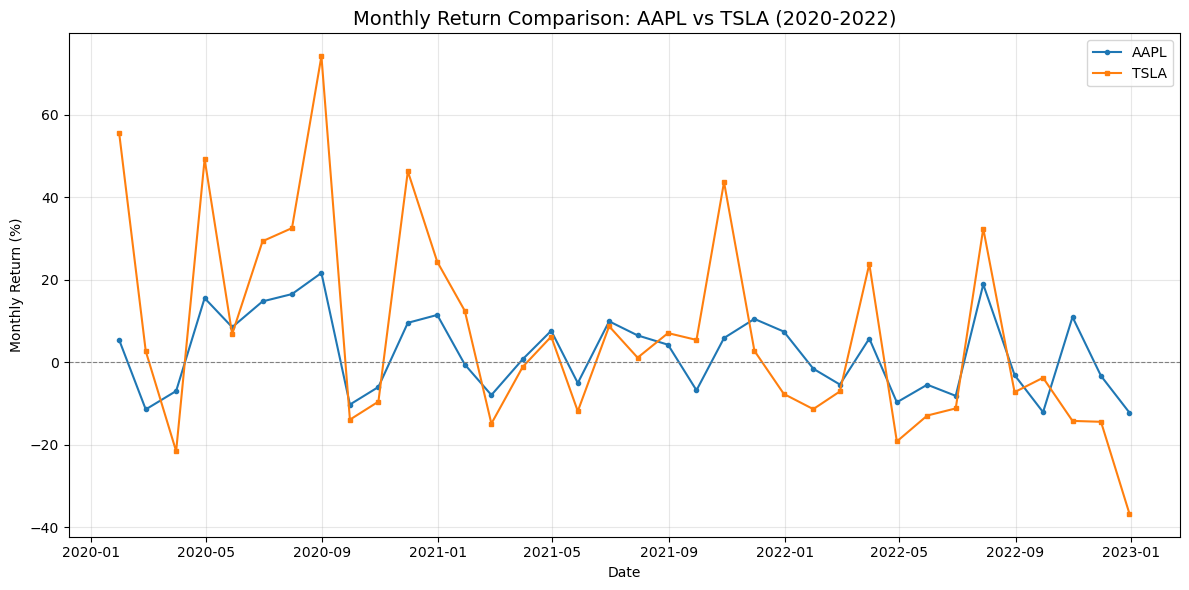

Chart saved as monthly_returns_comparison.png


In [17]:
# Plot line chart
plt.figure(figsize=(12, 6))
plt.plot(df_aapl['date'], df_aapl['monthly_return']*100, marker='o', markersize=3, label='AAPL')
plt.plot(df_tsla['date'], df_tsla['monthly_return']*100, marker='s', markersize=3, label='TSLA')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Monthly Return Comparison: AAPL vs TSLA (2020-2022)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Monthly Return (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_returns_comparison.png', dpi=150)
plt.show()
print("Chart saved as monthly_returns_comparison.png")

In [18]:
# Save data to CSV
df_aapl.to_csv('AAPL_data.csv', index=False)
df_tsla.to_csv('TSLA_data.csv', index=False)
print("Data saved to CSV files")

Data saved to CSV files
